In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson


---
# Aperçu de Yt

In [19]:
data=pd.read_csv("velib_horaire.csv")
data["Departure_Time"]= pd.to_datetime(data["Departure_Time"])
data = data.sort_values("Departure_Time").set_index("Departure_Time")

print(data.head())


                     duree_moyenne_sec  proportion_velos_electriques  \
Departure_Time                                                         
2024-05-01 00:00:00        1066.162766                      0.588298   
2024-05-01 01:00:00        1190.689723                      0.570299   
2024-05-01 02:00:00        1186.409469                      0.543506   
2024-05-01 03:00:00        1172.889674                      0.562500   
2024-05-01 04:00:00        1112.989264                      0.565184   

                     nombre_trajets  
Departure_Time                       
2024-05-01 00:00:00            4700  
2024-05-01 01:00:00            3542  
2024-05-01 02:00:00            3126  
2024-05-01 03:00:00            1840  
2024-05-01 04:00:00            1304  


In [ ]:
Y=data["nombre_trajets"]

print("Moyenne :", Y.mean())
print("Variance :", Y.var())
print("Écart-type :", Y.std())

Moyenne : 6016.092361111111
Variance : 17630569.02898957
Écart-type : 4198.877115252311


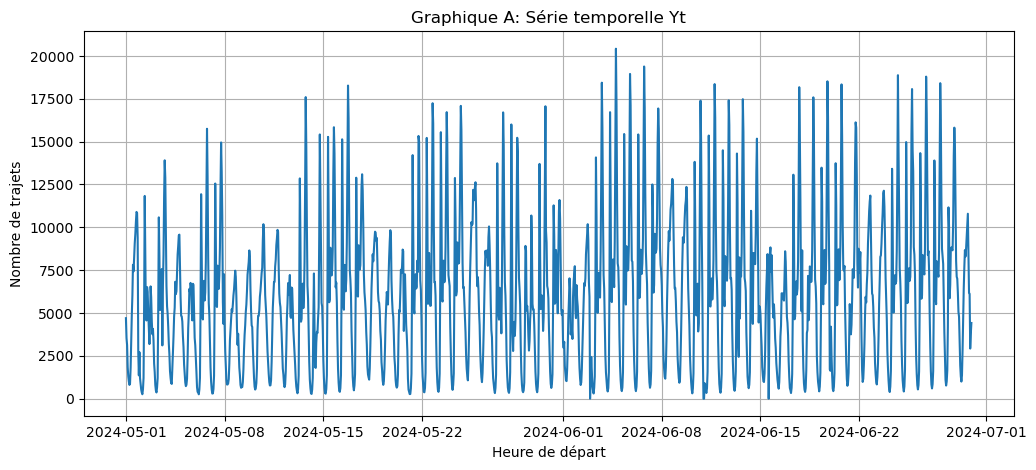

In [24]:
plt.figure(figsize=(12, 5))
plt.plot(Y)
plt.title("Graphique A: Série temporelle Yt")
plt.xlabel("Heure de départ")
plt.ylabel("Nombre de trajets")
plt.grid(True)
plt.show()

In [60]:
print("p-value ADF :", adfuller(Y)[1])

p-value ADF : 0.0019846903268409743


---

# Recherche d'une tendance polynomiale

In [ ]:
# test d'une tendance polynomiale de degré 2
t = np.arange(len(Y))
X = sm.add_constant(np.column_stack([t, t**2]))
mod = sm.OLS(Y.values, X).fit()
print(mod.summary())

- la tendance quadratique n’est pas retenue car $t^2$ a une p-value de 0.177, donc non significative.
- la tendance linéaire est significative car $t$ a une p-value de 0.007, mais R-squared=0.022, donc elle explique seulement 2.2 % de la variabilité.

In [53]:
# retrait de la tendance polynomiamle de degrès 1

X = sm.add_constant(t)

mod_lin = sm.OLS(Y.values, X).fit()

y_sans_tendance = Y - mod_lin.fittedvalues

---

# Recherche de saisonnalité

In [ ]:
profil_horaire = Y.groupby(Y.index.hour).mean()

plt.figure(figsize=(10,4))
plt.plot(profil_horaire.index, profil_horaire.values, marker="o")
plt.title("Moyenne du nombre de trajets par heure")
plt.xlabel("Heure")
plt.ylabel("Nombre moyen de trajets")
plt.grid(True)
plt.show()

In [ ]:
jours = ["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"]
profil_semaine = Y.groupby(Y.index.dayofweek).mean()

plt.figure(figsize=(8,4))
plt.plot(jours, profil_semaine.values, marker="o")
plt.title("Moyenne du nombre de trajets par jour de la semaine")
plt.xlabel("Jour")
plt.ylabel("Moyenne")
plt.grid(True)
plt.show()

In [ ]:
stl = STL(Y, period=24, robust=True)
res = stl.fit()

fig = res.plot()
fig.set_size_inches(14,10)
plt.show()

trend = res.trend
seasonal = res.seasonal
resid = res.resid

- La composante de tendance est lisse et oscille beaucoup plus lentement que la série initiale, mais le niveau moyen du nombre de trajets change au cours du temps, donc la série n’est probablement pas stationnaire 

- la composante de saisonnalité présente des pics et des creuc réguliers. Elle n’a pas une amplitude constante sur toute la période. Donc il peut rester une structure supplémentaire.

- les résidus sont proche de 0 mais ils ne sont pas homogène, ils ne ressemblent pas à un bruit blanc 

In [ ]:
stl = STL(Y, period=168, robust=True)
res = stl.fit()

fig = res.plot()
fig.set_size_inches(14,10)
plt.show()

trend = res.trend
seasonal = res.seasonal
resid = res.resid

- la composante de tendance est encore plus régulière et globalement croissante 
- La composante saisonnière présente un motif périodique stable
- les résidus demeurent dispersés de manière inégale et contiennent encore plusieurs valeurs extrêmes

In [57]:
# retrait de la saisonnalité

Y_diff = y_sans_tendance.diff(24).diff(168).dropna()

In [59]:
print("p-value ADF :", adfuller(Y_diff)[1])

p-value ADF : 3.686004040907482e-20


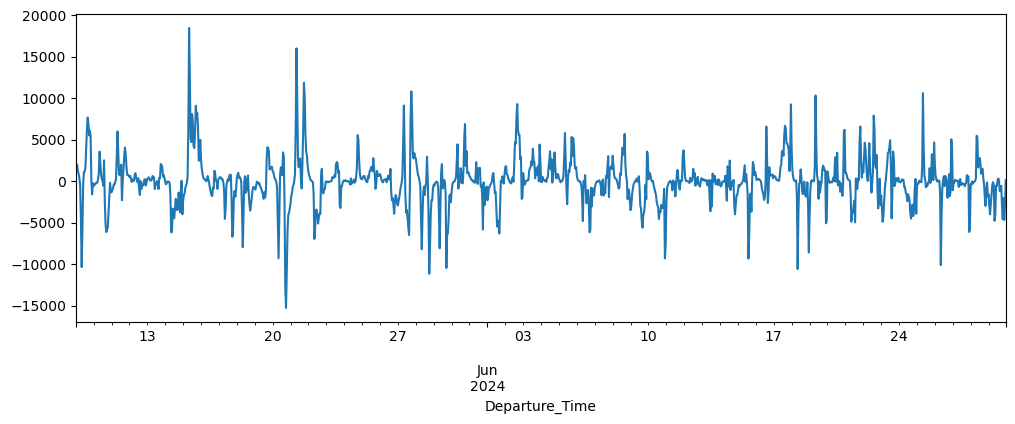

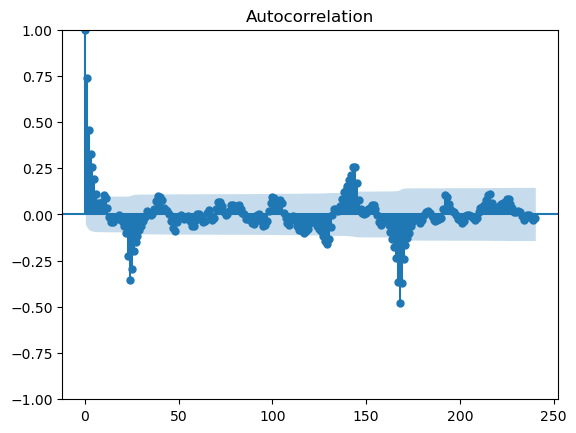

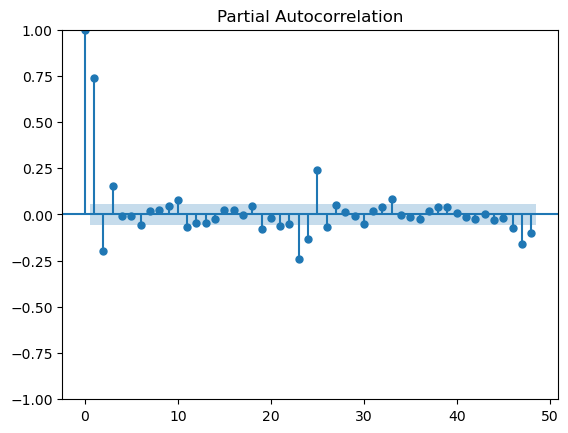

In [67]:
Y_diff.plot(figsize=(12,4))
plt.show()

plot_acf(Y_diff, lags=24*10)
plt.show()

plot_pacf(Y_diff, lags=48)
plt.show()


### ACF
- forte décroissance au début : dépendance de court terme ;
- pic marqué vers 24 : possible composante saisonnière résiduelle de type MA/AR ;
- pic marqué vers 168 : même idée au niveau hebdomadaire.

### PACF
- pic très fort au lag 1 ;
- pics autour de 24 et 48 ;


cela suggère qu’un simple ARMA(p,q) avec petits ordres ne capturera pas bien la structure. Le modèle SARIMA est plus adapté